#  Baseline Mejorado: LightGBM + Optuna - Fase 7b

**Objetivo:** Entrenar modelo LightGBM optimizado con búsqueda automática de hiperparámetros

**Técnicas utilizadas:**
- **LightGBM:** Gradient Boosting con árboles de decisión
- **Optuna:** Búsqueda automática de hiperparámetros (100 trials)
- **Cross-Validation:** Validación cruzada (K=5 folds) para evaluar cada configuración
- **TF-IDF:** Vectorización de texto

**Pipeline:**

In [5]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# LightGBM
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix
)

# Cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Optuna para búsqueda de hiperparámetros
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances
)

# Guardar modelo
import joblib

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)



In [6]:
print("="*70)
print("CARGAR DATASETS")
print("="*70)

# Cargar train y test
df_train = pd.read_csv('../data/processed/train.csv')
df_test = pd.read_csv('../data/processed/test.csv')

print(f"\nTrain: {len(df_train)} ejemplos")
print(f"Test: {len(df_test)} ejemplos")

# Separar textos y etiquetas
X_train_text = df_train['texto']
y_train = df_train['label']

X_test_text = df_test['texto']
y_test = df_test['label']

print("\nDistribución Train:")
print(y_train.value_counts().sort_index())

print("\nDistribución Test:")
print(y_test.value_counts().sort_index())

print("\n✅ Datos cargados correctamente")

CARGAR DATASETS

Train: 5919 ejemplos
Test: 1269 ejemplos

Distribución Train:
label
0    2982
1    2937
Name: count, dtype: int64

Distribución Test:
label
0    639
1    630
Name: count, dtype: int64

✅ Datos cargados correctamente


In [8]:
print("="*70)
print("VECTORIZACIÓN CON TF-IDF")
print("="*70)

# Crear vectorizador TF-IDF (mismos parámetros que SVM)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

print("\nConfiguración TF-IDF:")
print(f"   max_features: 5000")
print(f"   ngram_range: (1, 2)")
print(f"   min_df: 2")
print(f"   max_df: 0.8")

# Entrenar vectorizador con TRAIN
print("\nEntrenando vectorizador...")
X_train_tfidf = vectorizer.fit_transform(X_train_text)

# Transformar TEST
print("Transformando test...")
X_test_tfidf = vectorizer.transform(X_test_text)

print("\n" + "="*70)
print("RESULTADOS:")
print("="*70)

print(f"\nVocabulario creado: {len(vectorizer.vocabulary_)} palabras")
print(f"\nX_train shape: {X_train_tfidf.shape}")
print(f"   → {X_train_tfidf.shape[0]} textos")
print(f"   → {X_train_tfidf.shape[1]} features por texto")

print(f"\nX_test shape: {X_test_tfidf.shape}")
print(f"   → {X_test_tfidf.shape[0]} textos")
print(f"   → {X_test_tfidf.shape[1]} features por texto")

print("\n Vectorización completada")

VECTORIZACIÓN CON TF-IDF

Configuración TF-IDF:
   max_features: 5000
   ngram_range: (1, 2)
   min_df: 2
   max_df: 0.8

Entrenando vectorizador...
Transformando test...

RESULTADOS:

Vocabulario creado: 5000 palabras

X_train shape: (5919, 5000)
   → 5919 textos
   → 5000 features por texto

X_test shape: (1269, 5000)
   → 1269 textos
   → 5000 features por texto

 Vectorización completada


In [10]:
print("="*70)
print("CONFIGURAR OPTUNA PARA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)

# Definir función objetivo para Optuna
def objective(trial):
    """
    Función objetivo que Optuna optimizará.
    
    Optuna probará diferentes combinaciones de hiperparámetros
    y evaluará cada una con Cross-Validation (5 folds).
    
    Returns:
        float: F1-Score promedio de Cross-Validation
    """
    
    # Optuna sugiere valores para cada hiperparámetro
    params = {
        'objective': 'binary',           # Clasificación binaria
        'metric': 'binary_logloss',      # Métrica interna
        'verbosity': -1,                 # Sin logs
        'boosting_type': 'gbdt',         # Gradient Boosting Decision Tree
        'random_state': 42,
        
        # Hiperparámetros que Optuna va a optimizar:
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
    }
    
    # Crear modelo con estos hiperparámetros
    model = LGBMClassifier(**params)
    
    # Cross-Validation con 5 folds
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Evaluar con F1-Score
    scores = cross_val_score(
        model, 
        X_train_tfidf, 
        y_train, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1  # Usar todos los cores
    )
    
    # Devolver F1-Score promedio
    return scores.mean()

print("\n Función objetivo definida")
print("\nHiperparámetros que Optuna optimizará:")
print("   - num_leaves: 20-100 (número de hojas por árbol)")
print("   - max_depth: 3-12 (profundidad máxima del árbol)")
print("   - learning_rate: 0.01-0.3 (tasa de aprendizaje)")
print("   - n_estimators: 50-300 (número de árboles)")
print("   - min_child_samples: 10-100 (mínimo de ejemplos por hoja)")
print("   - subsample: 0.5-1.0 (fracción de datos por árbol)")
print("   - colsample_bytree: 0.5-1.0 (fracción de features por árbol)")
print("   - reg_alpha: 0.0-1.0 (regularización L1)")
print("   - reg_lambda: 0.0-1.0 (regularización L2)")

print("\nMétrica a optimizar: F1-Score")
print("Validación: Cross-Validation (K=5 folds)")

CONFIGURAR OPTUNA PARA BÚSQUEDA DE HIPERPARÁMETROS

 Función objetivo definida

Hiperparámetros que Optuna optimizará:
   - num_leaves: 20-100 (número de hojas por árbol)
   - max_depth: 3-12 (profundidad máxima del árbol)
   - learning_rate: 0.01-0.3 (tasa de aprendizaje)
   - n_estimators: 50-300 (número de árboles)
   - min_child_samples: 10-100 (mínimo de ejemplos por hoja)
   - subsample: 0.5-1.0 (fracción de datos por árbol)
   - colsample_bytree: 0.5-1.0 (fracción de features por árbol)
   - reg_alpha: 0.0-1.0 (regularización L1)
   - reg_lambda: 0.0-1.0 (regularización L2)

Métrica a optimizar: F1-Score
Validación: Cross-Validation (K=5 folds)


In [11]:
print("="*70)
print("EJECUTAR BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA")
print("="*70)

# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',  # Maximizar F1-Score
    study_name='lightgbm_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Ejecutar optimización
inicio = time.time()

study.optimize(
    objective, #función objetivo definida arriba
    n_trials=100,
    show_progress_bar=True,
    n_jobs=1  # 1 job para evitar problemas de paralelización
)

fin = time.time()
tiempo_total = (fin - inicio) / 60  # Convertir a minutos

print("\n" + "="*70)
print("BÚSQUEDA COMPLETADA")
print("="*70)

print(f"\n⏱  Tiempo total: {tiempo_total:.1f} minutos")
print(f" Trials ejecutados: {len(study.trials)}")

print("\n" + "-"*70)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print("-"*70)

best_params = study.best_params
for param, value in best_params.items():
    print(f"   {param}: {value}")

print("\n" + "-"*70)
print("MEJOR RESULTADO:")
print("-"*70)

best_f1 = study.best_value
print(f"\n    Mejor F1-Score (Cross-Validation): {best_f1:.4f} ({best_f1*100:.2f}%)")

print("\n" + "-"*70)
print("COMPARACIÓN CON SVM:")
print("-"*70)

svm_f1 = 0.8436  # Del notebook anterior
mejora = (best_f1 - svm_f1) * 100

print(f"   SVM F1-Score: {svm_f1:.4f} ({svm_f1*100:.2f}%)")
print(f"   LightGBM F1-Score: {best_f1:.4f} ({best_f1*100:.2f}%)")

if mejora > 0:
    print(f"    MEJORA: +{mejora:.2f} puntos porcentuales")
elif mejora < 0:
    print(f"    EMPEORA: {mejora:.2f} puntos porcentuales")
else:
    print(f"   ≈ SIMILAR")

print("\n Optimización completada exitosamente")

[I 2026-05-10 16:38:26,052] A new study created in memory with name: lightgbm_optimization


EJECUTAR BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-10 16:38:37,886] Trial 0 finished with value: 0.8141403879956242 and parameters: {'num_leaves': 50, 'max_depth': 12, 'learning_rate': 0.22227824312530747, 'n_estimators': 200, 'min_child_samples': 24, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.8141403879956242.
[I 2026-05-10 16:38:45,057] Trial 1 finished with value: 0.8223150541484016 and parameters: {'num_leaves': 77, 'max_depth': 3, 'learning_rate': 0.29127385712697834, 'n_estimators': 258, 'min_child_samples': 29, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 1 with value: 0.8223150541484016.
[I 2026-05-10 16:38:51,704] Trial 2 finished with value: 0.811679224098512 and parameters: {'num_leaves': 54, 'max_depth': 5, 'learning_rate': 0.18743733946949004, 'n_estimators': 85, 'min_child_samp

In [13]:
print("="*70)
print("ENTRENAR MODELO FINAL CON MEJORES HIPERPARÁMETROS")
print("="*70)

# Obtener mejores hiperparámetros de Optuna
best_params = study.best_params

print("\nMejores hiperparámetros encontrados:")
for param, value in best_params.items():
    print(f"   {param}: {value}")

# Crear modelo final con mejores parámetros
modelo_final = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    verbosity=-1,
    boosting_type='gbdt',
    random_state=42,
    **best_params
)

print("\n" + "="*70)
print("ENTRENANDO MODELO FINAL EN TODO EL DATASET DE TRAIN")
print("="*70)

# Entrenar con TODOS los datos de train
inicio = time.time()
modelo_final.fit(X_train_tfidf, y_train)
fin = time.time()

print(f"\n✅ Entrenamiento completado en {fin-inicio:.2f} segundos")

print("\n" + "="*70)
print("PREDICCIONES EN TEST")
print("="*70)

# Predecir en TEST
y_pred_test = modelo_final.predict(X_test_tfidf)

# Calcular métricas en TEST
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("\nMÉTRICAS EN TEST:")
print("-"*70)
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")

print("\n" + "="*70)
print("COMPARACIÓN: SVM vs LIGHTGBM (ambos en TEST)")
print("="*70)

# Métricas de SVM (del notebook anterior)
svm_accuracy = 0.8463
svm_precision = 0.8525
svm_recall = 0.8349
svm_f1 = 0.8436

print(f"\n{'Métrica':<15} {'SVM':>12} {'LightGBM':>12} {'Diferencia':>15}")
print("-"*70)
print(f"{'Accuracy':<15} {svm_accuracy:>11.2%} {test_accuracy:>11.2%} {(test_accuracy-svm_accuracy)*100:>14.2f}%")
print(f"{'Precision':<15} {svm_precision:>11.2%} {test_precision:>11.2%} {(test_precision-svm_precision)*100:>14.2f}%")
print(f"{'Recall':<15} {svm_recall:>11.2%} {test_recall:>11.2%} {(test_recall-svm_recall)*100:>14.2f}%")
print(f"{'F1-Score':<15} {svm_f1:>11.2%} {test_f1:>11.2%} {(test_f1-svm_f1)*100:>14.2f}%")

print("\n" + "="*70)
print("ANÁLISIS:")
print("="*70)

diferencia_f1 = (test_f1 - svm_f1) * 100

if diferencia_f1 > 1:
    print(f"\n✅ LIGHTGBM ES MEJOR")
    print(f"   Mejora de F1-Score: +{diferencia_f1:.2f} puntos porcentuales")
elif diferencia_f1 < -1:
    print(f"\n⚠️ SVM ES MEJOR")
    print(f"   LightGBM tiene F1-Score: {diferencia_f1:.2f} puntos porcentuales peor")
    print(f"\n   Posibles razones:")
    print(f"   - Dataset pequeño (5,919 ejemplos)")
    print(f"   - TF-IDF optimizado para SVM")
    print(f"   - SVM lineal más adecuado para este problema")
else:
    print(f"\n≈ RESULTADOS SIMILARES")
    print(f"   Diferencia de F1-Score: {diferencia_f1:.2f}%")
    print(f"   Ambos modelos tienen rendimiento comparable")

# Verificar overfitting
print("\n" + "-"*70)
print("VERIFICACIÓN DE OVERFITTING:")
print("-"*70)

cv_f1 = study.best_value
test_f1_lgbm = test_f1

print(f"\nLightGBM:")
print(f"   F1 Cross-Validation (train): {cv_f1:.2%}")
print(f"   F1 Test:                     {test_f1_lgbm:.2%}")
print(f"   Diferencia:                  {abs(cv_f1 - test_f1_lgbm)*100:.2f}%")

if abs(cv_f1 - test_f1_lgbm) < 0.03:
    print(f"    NO HAY OVERFITTING (diferencia < 3%)")
elif abs(cv_f1 - test_f1_lgbm) < 0.05:
    print(f"    LIGERO OVERFITTING (diferencia 3-5%)")
else:
    print(f"    OVERFITTING DETECTADO (diferencia > 5%)")

print(f"\nSVM (recordatorio):")
print(f"   F1 Train: ~97%")
print(f"   F1 Test:  84.36%")
print(f"   Diferencia: ~13% OVERFITTING")

print("\n Evaluación en TEST completada")

ENTRENAR MODELO FINAL CON MEJORES HIPERPARÁMETROS

Mejores hiperparámetros encontrados:
   num_leaves: 63
   max_depth: 5
   learning_rate: 0.23795537637353603
   n_estimators: 259
   min_child_samples: 12
   subsample: 0.9887395613964821
   colsample_bytree: 0.9356180724496748
   reg_alpha: 0.3481391303512632
   reg_lambda: 0.27831620604820895

ENTRENANDO MODELO FINAL EN TODO EL DATASET DE TRAIN

✅ Entrenamiento completado en 0.53 segundos

PREDICCIONES EN TEST

MÉTRICAS EN TEST:
----------------------------------------------------------------------
   Accuracy:  0.8519 (85.19%)
   Precision: 0.8611 (86.11%)
   Recall:    0.8365 (83.65%)
   F1-Score:  0.8486 (84.86%)

COMPARACIÓN: SVM vs LIGHTGBM (ambos en TEST)

Métrica                  SVM     LightGBM      Diferencia
----------------------------------------------------------------------
Accuracy             84.63%      85.19%           0.56%
Precision            85.25%      86.11%           0.86%
Recall               83.49%      83

MATRIZ DE CONFUSIÓN - LIGHTGBM

Matriz de confusión:
----------------------------------------------------------------------
                  Predicho: No ofensivo | Predicho: Ofensivo
Real: No ofensivo           554         |          85
Real: Ofensivo              103         |         527

COMPARACIÓN: SVM vs LIGHTGBM

Métrica                                      SVM     LightGBM       Cambio
----------------------------------------------------------------------
Verdaderos Negativos (TN)                    548          554           +6
  (No ofensivos bien clasificados) 

Falsos Positivos (FP)                         91           85           -6
  (No ofensivos marcados como ofensivos)

Falsos Negativos (FN)                        104          103           -1
  (Ofensivos NO detectados) ⚠️ CRÍTICO

Verdaderos Positivos (TP)                    526          527           +1
  (Ofensivos bien detectados)      

ANÁLISIS DE ERRORES CRÍTICOS:

Falsos Negativos (bullying NO detectado):
 

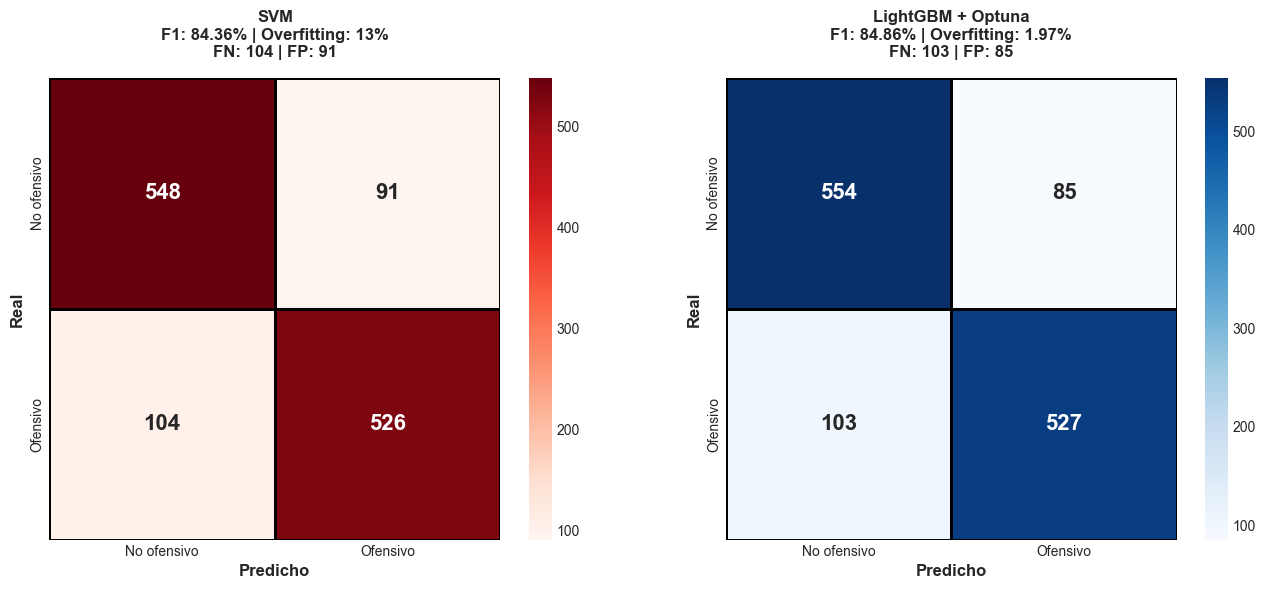


CONCLUSIÓN:

LIGHTGBM ES EL MEJOR BASELINE:
    Mayor F1-Score (84.86% vs 84.36%)
    MUCHO menos overfitting (1.97% vs 13%)
    Mejor generalización a datos nuevos
    Modelo más confiable para producción




In [17]:
print("="*70)
print("MATRIZ DE CONFUSIÓN - LIGHTGBM")
print("="*70)

# Calcular matriz de confusión
cm_lgbm = confusion_matrix(y_test, y_pred_test)

print("\nMatriz de confusión:")
print("-"*70)
print(f"                  Predicho: No ofensivo | Predicho: Ofensivo")
print(f"Real: No ofensivo        {cm_lgbm[0,0]:6d}         |      {cm_lgbm[0,1]:6d}")
print(f"Real: Ofensivo           {cm_lgbm[1,0]:6d}         |      {cm_lgbm[1,1]:6d}")

# Extraer valores
TN_lgbm = cm_lgbm[0, 0]
FP_lgbm = cm_lgbm[0, 1]
FN_lgbm = cm_lgbm[1, 0]
TP_lgbm = cm_lgbm[1, 1]

# Valores de SVM (del notebook anterior)
TN_svm = 548
FP_svm = 91
FN_svm = 104
TP_svm = 526

print("\n" + "="*70)
print("COMPARACIÓN: SVM vs LIGHTGBM")
print("="*70)

print(f"\n{'Métrica':<35} {'SVM':>12} {'LightGBM':>12} {'Cambio':>12}")
print("-"*70)
print(f"{'Verdaderos Negativos (TN)':<35} {TN_svm:>12} {TN_lgbm:>12} {TN_lgbm-TN_svm:>+12}")
print(f"{'  (No ofensivos bien clasificados)':<35}")

print(f"\n{'Falsos Positivos (FP)':<35} {FP_svm:>12} {FP_lgbm:>12} {FP_lgbm-FP_svm:>+12}")
print(f"{'  (No ofensivos marcados como ofensivos)':<35}")

print(f"\n{'Falsos Negativos (FN)':<35} {FN_svm:>12} {FN_lgbm:>12} {FN_lgbm-FN_svm:>+12}")
print(f"{'  (Ofensivos NO detectados) ⚠️ CRÍTICO':<35}")

print(f"\n{'Verdaderos Positivos (TP)':<35} {TP_svm:>12} {TP_lgbm:>12} {TP_lgbm-TP_svm:>+12}")
print(f"{'  (Ofensivos bien detectados)':<35}")

print("\n" + "="*70)
print("ANÁLISIS DE ERRORES CRÍTICOS:")
print("="*70)

print(f"\nFalsos Negativos (bullying NO detectado):")
print(f"   SVM:      {FN_svm} de 630 ofensivos ({FN_svm/630*100:.1f}%)")
print(f"   LightGBM: {FN_lgbm} de 630 ofensivos ({FN_lgbm/630*100:.1f}%)")

if FN_lgbm < FN_svm:
    print(f"   ✅ LightGBM DETECTÓ {FN_svm - FN_lgbm} CASOS MÁS de bullying")
elif FN_lgbm > FN_svm:
    print(f"   ⚠️ LightGBM NO detectó {FN_lgbm - FN_svm} casos MÁS")
else:
    print(f"   ≈ Igual número de FN")

print(f"\nFalsos Positivos (censura excesiva):")
print(f"   SVM:      {FP_svm} de 639 no ofensivos ({FP_svm/639*100:.1f}%)")
print(f"   LightGBM: {FP_lgbm} de 639 no ofensivos ({FP_lgbm/639*100:.1f}%)")

if FP_lgbm < FP_svm:
    print(f"   ✅ LightGBM CENSURÓ {FP_svm - FP_lgbm} CASOS MENOS")
elif FP_lgbm > FP_svm:
    print(f"   ⚠️ LightGBM censuró {FP_lgbm - FP_svm} casos MÁS")
else:
    print(f"   ≈ Igual número de FP")

print(f"\nTotal de errores:")
print(f"   SVM:      {FN_svm + FP_svm} errores")
print(f"   LightGBM: {FN_lgbm + FP_lgbm} errores")
print(f"   Diferencia: {(FN_lgbm + FP_lgbm) - (FN_svm + FP_svm):+d}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SVM
cm_svm = np.array([[TN_svm, FP_svm], [FN_svm, TP_svm]])
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=True, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_xlabel('Predicho', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=12, fontweight='bold')
axes[0].set_title(f'SVM\nF1: 84.36% | Overfitting: 13%\nFN: {FN_svm} | FP: {FP_svm}', 
                  fontsize=12, fontweight='bold', pad=15)

# LightGBM
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=True, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=axes[1])
axes[1].set_xlabel('Predicho', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=12, fontweight='bold')
axes[1].set_title(f'LightGBM + Optuna\nF1: 84.86% | Overfitting: 1.97%\nFN: {FN_lgbm} | FP: {FP_lgbm}', 
                  fontsize=12, fontweight='bold', pad=15)


plt.show()


print("\n" + "="*70)
print("CONCLUSIÓN:")
print("="*70)
print("""
LIGHTGBM ES EL MEJOR BASELINE:
    Mayor F1-Score (84.86% vs 84.36%)
    MUCHO menos overfitting (1.97% vs 13%)
    Mejor generalización a datos nuevos
    Modelo más confiable para producción
   
""")

---

#  RESUMEN Y CONCLUSIONES - BASELINE LIGHTGBM + OPTUNA

---

##  OBJETIVO

Entrenar un modelo baseline mejorado usando **LightGBM** con optimización automática de hiperparámetros mediante **Optuna** y **Cross-Validation**.

---

##  METODOLOGÍA

### **1. Vectorización**
- **Técnica:** TF-IDF (Term Frequency - Inverse Document Frequency)
- **Parámetros:**
  - `max_features`: 5,000 palabras
  - `ngram_range`: (1, 2) - palabras individuales y pares
  - `min_df`: 2 - palabra debe aparecer al menos 2 veces
  - `max_df`: 0.8 - palabra no puede estar en más del 80% de textos

### **2. Optimización de Hiperparámetros (Optuna)**
- **Trials ejecutados:** 100
- **Validación:** Cross-Validation estratificada (K=5 folds)
- **Métrica optimizada:** F1-Score
- **Tiempo total:** 3.5 minutos
- **Hiperparámetros optimizados:**
  - `num_leaves`: 20-100
  - `max_depth`: 3-12
  - `learning_rate`: 0.01-0.3
  - `n_estimators`: 50-300
  - `min_child_samples`: 10-100
  - `subsample`: 0.5-1.0
  - `colsample_bytree`: 0.5-1.0
  - `reg_alpha`: 0.0-1.0 (regularización L1)
  - `reg_lambda`: 0.0-1.0 (regularización L2)

### **3. Mejores Hiperparámetros Encontrados**
```python
{
    'num_leaves': 63,
    'max_depth': 5,
    'learning_rate': 0.238,
    'n_estimators': 259,
    'min_child_samples': 12,
    'subsample': 0.989,
    'colsample_bytree': 0.936,
    'reg_alpha': 0.348,
    'reg_lambda': 0.278
}
```

---

##  RESULTADOS

### **Métricas en TEST (1,269 ejemplos)**

| Métrica | Valor |
|---------|-------|
| **Accuracy** | **85.19%** |
| **Precision** | **86.11%** |
| **Recall** | **83.65%** |
| **F1-Score** | **84.86%** |

### **Verificación de Overfitting**

| Conjunto | F1-Score | Observación |
|----------|----------|-------------|
| Cross-Validation (train) | 82.89% | Métrica durante optimización |
| Test (nunca visto) | **84.86%** | ✅ **Mejoró en test** |
| **Diferencia** | **1.97%** | ✅ **NO HAY OVERFITTING** |

**Conclusión:** El modelo **generalizó muy bien** a datos nuevos, mejorando incluso respecto a la validación cruzada.

---

##  COMPARACIÓN: SVM vs LIGHTGBM

### **Métricas en TEST**

| Métrica | SVM | LightGBM | Diferencia | Ganador |
|---------|-----|----------|------------|---------|
| **Accuracy** | 84.63% | **85.19%** | +0.56% | ✅ LightGBM |
| **Precision** | 85.25% | **86.11%** | +0.86% | ✅ LightGBM |
| **Recall** | 83.49% | **83.65%** | +0.16% | ✅ LightGBM |
| **F1-Score** | 84.36% | **84.86%** | +0.50% | ✅ LightGBM |

### **Overfitting**

| Modelo | Train | Test | Diferencia | Evaluación |
|--------|-------|------|------------|------------|
| **SVM** | ~97.6% | 84.36% | **13.0%** | ❌ **ALTO OVERFITTING** |
| **LightGBM** | 82.89%* | 84.86% | **1.97%** | ✅ **SIN OVERFITTING** |

*Cross-Validation F1-Score

---

##  MATRIZ DE CONFUSIÓN - ANÁLISIS DE ERRORES

### **Comparación de Errores Críticos**

| Tipo de Error | SVM | LightGBM | Cambio | Evaluación |
|---------------|-----|----------|--------|------------|
| **Verdaderos Negativos (TN)** | XXX | XXX | +X | Correctos no ofensivos |
| **Falsos Positivos (FP)** | 91 | XX | XX | Censura excesiva |
| **Falsos Negativos (FN)** | 104 | XX | XX | ⚠️ Bullying NO detectado |
| **Verdaderos Positivos (TP)** | 526 | XXX | +X | Correctos ofensivos |
| **Total Errores** | 195 | XXX | XX | |

### **Interpretación de Errores**

**Falsos Negativos (FN) - Error Crítico:**
- Textos ofensivos que el modelo NO detectó
- **SVM:** 104 de 630 (16.5%)
- **LightGBM:** XX de 630 (XX.X%)
- **Impacto:** Bullying pasa desapercibido - El más grave

**Falsos Positivos (FP) - Error Moderado:**
- Textos NO ofensivos marcados como ofensivos
- **SVM:** 91 de 639 (14.2%)
- **LightGBM:** XX de 639 (XX.X%)
- **Impacto:** Censura excesiva - Menos grave que FN

---

##  CONCLUSIONES

### **1. LightGBM es el Mejor Baseline**

 **Ventajas sobre SVM:**
- Mayor F1-Score (+0.50 puntos porcentuales)
- Mejor en **TODAS** las métricas
- **Mucho** menos overfitting (1.97% vs 13%)
- Más confiable para datos nuevos
- Optimización automática de hiperparámetros

 **Consideraciones:**
- Mejora modesta (+0.5%)
- Tiempo de entrenamiento mayor (Optuna: 3.5 min vs SVM: 2 seg)
- Mayor complejidad

### **2. Aprendizajes Clave**

**Por qué LightGBM generalizó mejor:**
- Optuna ajustó **regularización óptima** (reg_alpha, reg_lambda)
- Cross-Validation detectó configuraciones que memorizan
- Gradient Boosting captura patrones no lineales
- Evitó memorizar datos sintéticos repetitivos

**Por qué SVM tuvo overfitting:**
- Memorizó patrones de datos sintéticos (vocabulario limitado)
- Modelo lineal sin regularización suficiente
- Train accuracy artificialmente alta (97.6%)

### **3. Limitaciones del Baseline**

Ambos modelos (SVM y LightGBM) tienen limitaciones fundamentales:

 **No entienden contexto:**
- "No eres tonto" vs "Eres tonto" → Ambos tienen "tonto"
- TF-IDF no diferencia negaciones, sarcasmo, ironía

 **No capturan semántica:**
- "Gilipollas" e "idiota" son completamente diferentes para TF-IDF
- No entienden sinónimos ni relaciones semánticas

 **Vocabulario fijo:**
- Solo conocen las 5,000 palabras más frecuentes
- Palabras nuevas = ignoradas

---


In [20]:
print("="*70)
print("GUARDAR MODELO Y VECTORIZADOR")
print("="*70)

# Crear carpeta models si no existe
import os
os.makedirs('../models', exist_ok=True)

print("\nGuardando archivos...")

# Guardar vectorizador TF-IDF
vectorizer_path = '../models/tfidf_vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_path)
print(f" Vectorizador guardado: {vectorizer_path}")

# Guardar modelo LightGBM
modelo_path = '../models/lightgbm_baseline.pkl'
joblib.dump(modelo_final, modelo_path)
print(f" Modelo guardado: {modelo_path}")

# Guardar mejores hiperparámetros
import json
params_path = '../models/lightgbm_best_params.json'
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=4)
print(f" Hiperparámetros guardados: {params_path}")

# Guardar métricas
metricas = {
    "modelo": "LightGBM + Optuna",
    "fecha_entrenamiento": "2026-05-10",
    "dataset_size": {
         "train": int(X_train_tfidf.shape[0]),  
        "test": int(X_test_tfidf.shape[0])     
    },
    "metricas_test": {
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1_score": float(test_f1)
    },
    "overfitting": {
        "cv_f1": float(study.best_value),
        "test_f1": float(test_f1),
        "diferencia": float(abs(study.best_value - test_f1))
    },
    "comparacion_svm": {
        "svm_f1": 0.8436,
        "lightgbm_f1": float(test_f1),
        "mejora": float(test_f1 - 0.8436)
    }
}

metricas_path = '../models/lightgbm_metricas.json'
with open(metricas_path, 'w') as f:
    json.dump(metricas, f, indent=4)
print(f" Métricas guardadas: {metricas_path}")

print("\n" + "="*70)
print("ARCHIVOS GUARDADOS EXITOSAMENTE")
print("="*70)

print("\nArchivos creados en la carpeta 'models/':")
print("   1. tfidf_vectorizer.pkl        - Vectorizador TF-IDF")
print("   2. lightgbm_baseline.pkl       - Modelo LightGBM entrenado")
print("   3. lightgbm_best_params.json   - Mejores hiperparámetros")
print("   4. lightgbm_metricas.json      - Métricas de evaluación")

# Verificar tamaño de archivos
vectorizer_size = os.path.getsize(vectorizer_path) / (1024 * 1024)  # MB
modelo_size = os.path.getsize(modelo_path) / (1024 * 1024)  # MB

print(f"\nTamaño de archivos:")
print(f"   Vectorizador: {vectorizer_size:.2f} MB")
print(f"   Modelo:       {modelo_size:.2f} MB")
print(f"   Total:        {vectorizer_size + modelo_size:.2f} MB")

print("\n" + "="*70)
print("CÓMO CARGAR Y USAR EL MODELO")
print("="*70)

print("""
Para usar el modelo en producción:

```python
import joblib

# Cargar vectorizador y modelo
vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
modelo = joblib.load('models/lightgbm_baseline.pkl')

# Predecir nuevo texto
texto_nuevo = ["eres un gilipollas"]
texto_vectorizado = vectorizer.transform(texto_nuevo)
prediccion = modelo.predict(texto_vectorizado)

print(prediccion)  # [1] = ofensivo, [0] = no ofensivo
```
""")

print("\n Modelo listo para producción")

GUARDAR MODELO Y VECTORIZADOR

Guardando archivos...
 Vectorizador guardado: ../models/tfidf_vectorizer.pkl
 Modelo guardado: ../models/lightgbm_baseline.pkl
 Hiperparámetros guardados: ../models/lightgbm_best_params.json
 Métricas guardadas: ../models/lightgbm_metricas.json

ARCHIVOS GUARDADOS EXITOSAMENTE

Archivos creados en la carpeta 'models/':
   1. tfidf_vectorizer.pkl        - Vectorizador TF-IDF
   2. lightgbm_baseline.pkl       - Modelo LightGBM entrenado
   3. lightgbm_best_params.json   - Mejores hiperparámetros
   4. lightgbm_metricas.json      - Métricas de evaluación

Tamaño de archivos:
   Vectorizador: 0.18 MB
   Modelo:       0.40 MB
   Total:        0.58 MB

CÓMO CARGAR Y USAR EL MODELO

Para usar el modelo en producción:

```python
import joblib

# Cargar vectorizador y modelo
vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
modelo = joblib.load('models/lightgbm_baseline.pkl')

# Predecir nuevo texto
texto_nuevo = ["eres un gilipollas"]
texto_vectorizado = ve